In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))
from pricing_engine.safety import SafetyLayer, SafetyConfig

# Module 04: Safety & Latency Validation
**Objective:** Validate O(1) constraints and prove <5ms latency.



In [3]:

# SETUP
safety = SafetyLayer(SafetyConfig(
    max_daily_change_pct=0.20,
    min_margin_dollars=15.0
))

constraints = {
    'min_price': 80.0,
    'max_price': 400.0,
    'cost_basis': 70.0  # Floor becomes 70+15 = 85
}

print(f"Effective Floor: $85.00")
print(f"Effective Ceiling: $400.00")


Effective Floor: $85.00
Effective Ceiling: $400.00


## 2. Logic Test: The Rogue Bandit
Bandit attempts unsafe actions.

In [4]:
scenarios = [
    {'name': 'Lowball', 'input': 50.0, 'prev': 100.0, 'expected': 85.0}, # Hit Cost Floor
    {'name': 'Gouge', 'input': 1000.0, 'prev': 100.0, 'expected': 120.0}, # Hit Smoothness Cap (100 + 20%)
    {'name': 'Crash', 'input': 1.0, 'prev': 100.0, 'expected': 85.0},   # Hit Floor
    {'name': 'Valid', 'input': 110.0, 'prev': 100.0, 'expected': 110.0}, # OK
]

print("--- Logic Trace ---")
passes = 0
for s in scenarios:
    res = safety.validate_and_clamp(s['input'], constraints, prev_price=s['prev'])
    
    status = "✅" if res.safe_price == s['expected'] else "❌"
    if status == "✅": passes += 1
        
    print(f"{status} {s['name']}: Input ${s['input']} -> Safe ${res.safe_price} (Reason: {res.trigger_reason})")

if passes == len(scenarios):
    print("\n✅ LOGIC PASS: All safety constraints enforced correctly.")
else:
    print("\n❌ LOGIC FAIL: Check implementation.")




--- Logic Trace ---
✅ Lowball: Input $50.0 -> Safe $85.0 (Reason: Floor)
✅ Gouge: Input $1000.0 -> Safe $120.0 (Reason: Ceiling|Smoothness_Rise)
✅ Crash: Input $1.0 -> Safe $85.0 (Reason: Floor)
✅ Valid: Input $110.0 -> Safe $110.0 (Reason: None)

✅ LOGIC PASS: All safety constraints enforced correctly.


## 3. Performance Benchmark (The 5ms Rule)
We simulate 100,000 requests to measure P99 latency.


--- Running Latency Benchmark (100k requests) ---
P50 Latency: 0.900 microseconds
P99 Latency: 2.200 microseconds
Max Latency: 0.301 ms


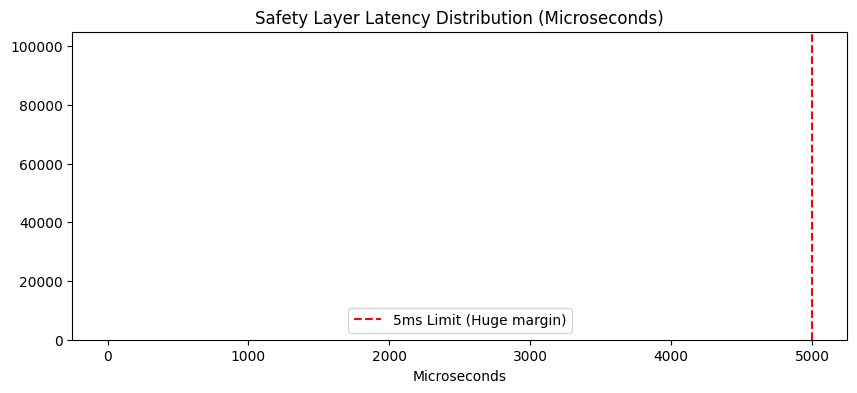

In [5]:
print("\n--- Running Latency Benchmark (100k requests) ---")

latencies = []
# Pre-generate inputs to isolate calculation time
inputs = np.random.uniform(10, 1000, 100000)

for p in inputs:
    res = safety.validate_and_clamp(p, constraints, prev_price=100.0)
    latencies.append(res.latency_ms)

latencies = np.array(latencies)

p50 = np.percentile(latencies, 50)
p99 = np.percentile(latencies, 99)
max_lat = np.max(latencies)

print(f"P50 Latency: {p50*1000:.3f} microseconds")
print(f"P99 Latency: {p99*1000:.3f} microseconds")
print(f"Max Latency: {max_lat:.3f} ms")

plt.figure(figsize=(10, 4))
plt.hist(latencies * 1000, bins=50, color='teal')
plt.title("Safety Layer Latency Distribution (Microseconds)")
plt.xlabel("Microseconds")
plt.axvline(5000, color='red', linestyle='--', label='5ms Limit (Huge margin)')
plt.legend()
plt.show()



## 4. Final Gate



In [6]:
if p99 < 5.0 and passes == len(scenarios):
    print("✅ DECISION: GO. Safety Layer is production-ready.")
else:
    print("❌ DECISION: NO-GO. Optimization required.")

✅ DECISION: GO. Safety Layer is production-ready.
